# Ejercicio 08 · Expediente de gobernanza y simulacro

Marlenis Judith Concepción Cuevas · INF-8239-C2 · Unidad IV

Integra LAB13 sobre el sistema del Ejercicio 07 (regla transparente en piloto limitado). Datos sintéticos.

In [1]:
import json, os, subprocess, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.chdir(ROOT)
subprocess.run([sys.executable, "scripts/run_e08.py"], check=True, capture_output=True)
pd.set_option("display.max_colwidth", 80)

## 1. Inventario, minimización y retención

In [2]:
display(pd.read_csv("docs/data_inventory.csv"))
json.loads(Path("reports/lab13/minimizacion_retencion.json").read_text())

,column,description,type,sensitivity,operational_view,audit_view,purpose,legal_basis_if_real,retention,minimization
0,case_id,Identificador seudónimo del caso,texto,seudónimo,yes,yes,Trazabilidad y apelación,Finalidad declarada (Ley 172-13),12 meses operativo / 24 meses auditoría,Sin relación con nombre ni documento
1,received_date,Fecha de recepción del caso,fecha,operativa,yes,yes,Orden temporal y retención,Finalidad declarada,igual que case_id,Solo fecha; sin hora
2,zone,Zona territorial (Norte/Sur/Este/Oeste),categórica,cuasi-identificador,no,yes,Auditoría por zona,Interés legítimo de auditoría,24 meses en vista de auditoría,Excluida de la regla elegida
3,protected_group,Grupo protegido sintético (G1/G2),categórica,sensible,no,yes,Solo auditoría de equidad,Obligación de no discriminación (Constitución art. 39),24 meses en vista de auditoría con acceso restringido,Nunca entra a la decisión
4,age_band,Rango de edad,categórica,sensible,no,yes,Auditoría interseccional,Obligación de no discriminación,24 meses en vista de auditoría con acceso restringido,Rangos y no edad exacta
5,previous_incidents,Incidentes previos registrados,entera,operativa,yes,yes,Variable de la regla,Finalidad declarada,igual que case_id,Necesaria para priorizar
6,infrastructure_score,Puntuación de infraestructura,decimal,operativa,no,yes,Solo auditoría y comparación con modelos,Finalidad declarada,24 meses en vista de auditoría,Excluida de la regla elegida
7,exposure,Exposición al riesgo (0-1),decimal,operativa,yes,yes,Variable de la regla,Finalidad declarada,igual que case_id,Necesaria para priorizar
8,target,Resultado observado tras la revisión,binaria,operativa,no,yes,Evaluación y monitoreo,Finalidad declarada,24 meses en vista de auditoría,No se muestra al analista antes de revisar


{'columnas_originales': ['case_id',
  'received_date',
  'zone',
  'protected_group',
  'age_band',
  'previous_incidents',
  'infrastructure_score',
  'exposure',
  'target'],
 'vista_operativa': ['case_id',
  'received_date',
  'previous_incidents',
  'exposure'],
 'vista_auditoria': ['case_id',
  'received_date',
  'zone',
  'protected_group',
  'age_band',
  'previous_incidents',
  'infrastructure_score',
  'exposure',
  'target'],
 'columnas_retiradas_de_la_operacion': ['age_band',
  'infrastructure_score',
  'protected_group',
  'target',
  'zone'],
 'simulacion_retencion': {'fecha_revision': '2027-06-30',
  'operativa': {'meses': 12, 'conservados': 316, 'eliminados': 324},
  'auditoria': {'meses': 24, 'conservados': 640, 'eliminados': 0}}}

## 2. Trazabilidad: manifiesto de hashes

In [3]:
pd.DataFrame(json.loads(Path('reports/lab13/manifest.json').read_text())).T

,path,sha256
dataset,data/territorial_risk_synthetic.csv,2af1858fe874f3914b0f9bfe068fd876cb716186694a6ece9a16e8c929128a01
configuracion,configs/governance.yml,e8f90325a8ed1c973b638ea94a2122c68f6435a4df8a6020b6fb2d000843df35
inventario,docs/data_inventory.csv,5cbabcd0326b85c75b3fb7e5fd0314ebc154b2f01d18890bd99180d102c22398
raci,student_inputs/raci.csv,05995509e0ef94a7190d542a18a7f803aa1ee6f331f31a4c7d6361afab156e28
decision_e07,reports/lab12/decision.json,4f1c0fd6922911ead92a665f3dd76c077539a1d9f423bab211cc095f63341c8c
datasheet,docs/DATASHEET.md,ec1ed58e94d740c1442d7baea65806e0ff96072f0ce35924164335b8ff3cb37d
model_card,docs/MODEL_CARD.md,998ceaccf99eb375362eeae37fb6c7bb9cc8ea6fb000c6d15c33032fa83a483d
runbook,docs/RUNBOOK.md,85962a3753d3fdc40117ee2791d858105031f120acccb7b63afc23d702f798cf


## 3. RACI

In [4]:
pd.read_csv('student_inputs/raci.csv')

,activity,R,A,C,I
0,Inventario y minimización de datos,Data Engineer,Data Protection Officer,Data Scientist,Product Owner
1,Retención y eliminación de datos,Data Engineer,Data Protection Officer,Legal,Product Owner
2,Calidad y contrato de datos,Data Engineer,Product Owner,Data Scientist,ML Engineer
3,Auditoría de equidad,Data Scientist,Product Owner,Community representatives,Institutional Owner
4,Validación de la regla o modelo,Data Scientist,Product Owner,Data Engineer,Operators
5,Decisión de despliegue o retiro,Product Owner,Institutional Owner,Legal and Data Scientist,Operators and community representatives
6,Monitoreo semanal y mensual,ML Engineer,Product Owner,Data Scientist,Operators
7,Respuesta a incidentes,ML Engineer,Institutional Owner,Legal and Data Scientist,Affected representatives
8,Atención de apelaciones,Operators,Product Owner,Data Scientist,Affected person
9,Comunicación a afectados,Product Owner,Institutional Owner,Legal,Community representatives


## 4. Monitoreo

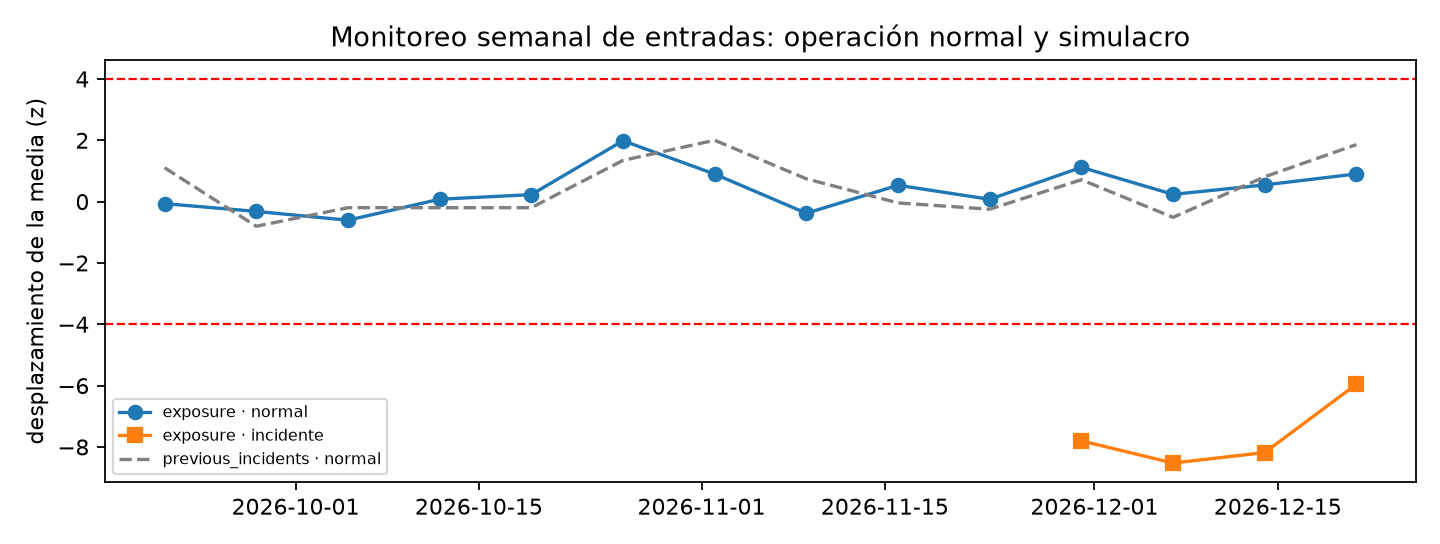

,semana,escenario,n,z_exposure,z_previous_incidents,alertas,estado
0,2026-09-21,normal,6,-0.07,1.10,NaN,OK
1,2026-09-28,normal,8,-0.32,-0.80,NaN,OK
2,2026-10-05,normal,14,-0.61,-0.20,NaN,OK
3,2026-10-12,normal,14,0.08,-0.20,NaN,OK
4,2026-10-19,normal,14,0.23,-0.20,NaN,OK
5,2026-10-26,normal,6,1.98,1.34,NaN,OK
6,2026-11-02,normal,14,0.90,2.00,NaN,OK
7,2026-11-09,normal,14,-0.38,0.74,NaN,OK
8,2026-11-16,normal,14,0.53,-0.04,NaN,OK
9,2026-11-23,normal,10,0.07,-0.25,NaN,OK


,corte,n,recall,recall_gap,fpr_gap,selection_rate,alertas
0,2026-10-31,60,0.656,0.020,0.096,0.50,ventana insuficiente: solo informativo
1,2026-11-30,100,0.755,0.104,0.149,0.56,NaN
2,2026-12-31,100,0.800,0.014,0.050,0.64,NaN


In [5]:
display(Image(filename="reports/lab13/monitoreo.png"))
display(pd.read_csv("reports/lab13/monitoreo_entradas.csv").round(2))
pd.read_csv("reports/lab13/monitoreo_desempeno.csv").round(3)

## 5. Simulacro y postmortem

In [6]:
display(json.loads(Path("reports/lab13/simulacro.json").read_text()))
Markdown(Path("reports/lab13/INCIDENT_POSTMORTEM.md").read_text())

{'casos_afectados_diciembre': 46,
 'positivos_reales': 29,
 'falsos_negativos_con_datos_correctos': 6,
 'falsos_negativos_si_nadie_detecta': 9,
 'casos_alto_riesgo_perdidos_si_nadie_detecta': 3,
 'casos_alto_riesgo_perdidos_en_primera_semana': 1,
 'recall_correcto': 0.7931034482758621,
 'recall_con_falla': 0.6896551724137931,
 'semana_deteccion': '2026-11-30',
 'z_deteccion': -7.801912998575131,
 'estado': 'CONTENER'}

# Postmortem · simulacro de incidente de datos

Simulacro ejecutado por `scripts/run_e08.py` sobre la línea temporal sintética. Valores calculados en `reports/lab13/simulacro.json`.

- **Escenario:** desde el 2026-12-01 la ingesta registra `exposure` multiplicada por 0.1 (cambio de unidad no comunicado).
- **Detección:** semana del 2026-11-30; `check_inputs` mide un desplazamiento de la media de exposure de -7.8 errores estándar (umbral ±4.0). Ninguna semana normal superó |z| = 2.0.
- **Clasificación:** severidad alta (deriva de una variable de decisión). Estado del runbook: **CONTENER**.
- **Contención:** el ML Engineer desactiva el orden sugerido y pasa a orden de llegada con revisión manual; autoriza el Institutional Owner (RACI: Respuesta a incidentes).
- **Evidencia preservada:** lote afectado, alertas (`monitoreo_entradas.csv`), hashes (`manifest.json`) y commit del código.
- **Impacto medido:** 46 casos en diciembre con 29 de alto riesgo. Si nadie lo detectara, el recall caería de 0.793 a 0.690 y se dejarían sin priorizar 3 casos de alto riesgo más; al detectarlo en la primera semana, la pérdida se limita a 1 caso(s), que se revisan de inmediato al volver a puntuar.
- **Comunicación:** interna el mismo día; el Product Owner informa a las comunidades de las zonas con casos reordenados y ofrece revisión prioritaria en 5 días hábiles.
- **Reversión:** volver a la versión anterior de la ingesta, volver a puntuar todos los casos desde el 2026-12-01 y revisar primero los casos de alto riesgo reordenados.
- **Causa raíz:** cambio de unidad en la fuente sin contrato de datos que fijara la escala.

## Acciones correctivas
| Acción | Responsable | Fecha límite |
|---|---|---|
| Añadir la escala y el rango esperado de `exposure` al contrato de datos | Data Engineer | 2026-12-15 |
| Prueba automática de deriva en cada carga (`check_inputs`) antes de puntuar | ML Engineer | 2026-12-15 |
| Protocolo de aviso de cambios de fuente entre proveedor de datos y Data Engineer | Product Owner | 2026-12-31 |
| Revisión del postmortem y cierre | Institutional Owner | 2027-01-08 |


## 6. Decisión

Se mantiene **LIMITAR** (Ejercicio 07): la regla transparente puede pasar a un piloto porque el expediente de gobernanza está completo y el simulacro demostró que la falla se detecta, se contiene y se revierte con responsables definidos. No se despliega de forma general hasta que cada celda interseccional tenga al menos 30 casos.